In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

In [5]:
df = pd.read_csv("customer_retail.csv")
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER       6.0   
1    536365     71053                  WHITE METAL LANTERN       6.0   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER       8.0   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE       6.0   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.       6.0   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  


In [6]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99005 entries, 0 to 99004
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    99005 non-null  object 
 1   StockCode    99005 non-null  object 
 2   Description  98707 non-null  object 
 3   Quantity     99004 non-null  float64
 4   InvoiceDate  99004 non-null  object 
 5   UnitPrice    99004 non-null  float64
 6   CustomerID   64478 non-null  float64
 7   Country      99004 non-null  object 
dtypes: float64(3), object(5)
memory usage: 6.0+ MB
None
InvoiceNo          0
StockCode          0
Description      298
Quantity           1
InvoiceDate        1
UnitPrice          1
CustomerID     34527
Country            1
dtype: int64


In [27]:
df = df.dropna()

In [8]:
le = LabelEncoder()

df["Country"] = le.fit_transform(df["Country"])

In [9]:
df["Target"] = (
    df["Quantity"] > df["Quantity"].median()
).astype(int)

In [10]:
X = df[["UnitPrice", "Country"]]

y = df["Target"]

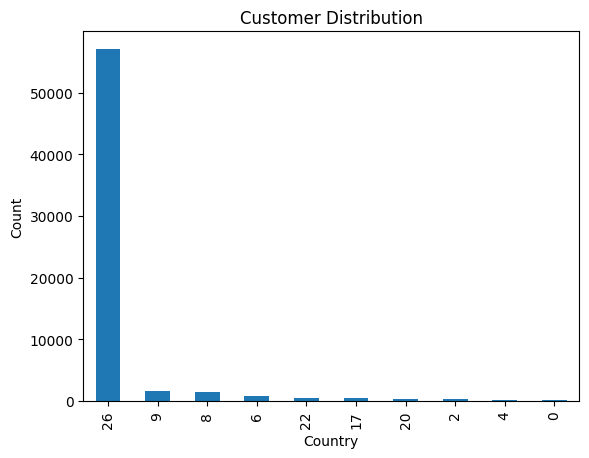

In [11]:
df["Country"].value_counts().head(10).plot(kind="bar")

plt.title("Customer Distribution")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
#logisticRegression

In [14]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [15]:
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Accuracy:", lr_acc)

Logistic Accuracy: 0.671681141439206


In [16]:
print(confusion_matrix(y_test, lr_pred))

[[3655 2786]
 [1448 5007]]


In [17]:
#Decision Tree

In [18]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [19]:
dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.6933933002481389


In [20]:
print(confusion_matrix(y_test, dt_pred))

[[3968 2473]
 [1481 4974]]


In [21]:
#KNN

In [22]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

In [23]:
knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.6542338709677419


In [24]:
print(confusion_matrix(y_test, knn_pred))

[[3804 2637]
 [1822 4633]]


In [25]:
#compare model

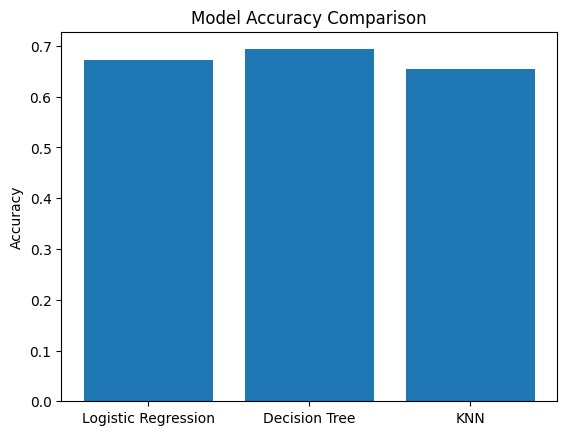

In [26]:
models = [
    "Logistic Regression",
    "Decision Tree",
    "KNN"
]

accuracies = [
    lr_acc,
    dt_acc,
    knn_acc
]

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()